# Computer Exercise 14.6 — Problem 1

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7th ed.)
> **단원**: §14.6 Online / Incremental Learning — Recursive Least Squares
> **풀이 일자**: 2026-07-06 (자동 생성)
> **언어**: 본문 한국어 / 그래프 라벨 영문

**주제**: 배치 최소제곱을 매 관측마다 갱신하는 **재귀 최소제곱(RLS)** 을 유도·구현하고, 정상(stationary) 데이터에서 배치 OLS 와 **수치적으로 동일**함을 보인다.

## 1. 문제 (원문)

> **1.** Data $(x_t, y_t)$ arrive one sample at a time from a stationary linear model
> $y = \phi(x)^\top \beta + \varepsilon$. Instead of re-solving the normal equations from scratch at
> every step (cost $\mathcal{O}(np^2)$ each), implement the **recursive least squares (RLS)** update,
> which refreshes the coefficient vector in $\mathcal{O}(p^2)$ per sample using the
> Sherman-Morrison identity. Verify that after $t$ samples the RLS estimate equals the batch
> ordinary-least-squares estimate on the same $t$ samples to machine precision, and plot the
> convergence of the coefficients toward their true values.

### 한국어 풀이용 정리
정상 선형모델에서 관측이 하나씩 도착한다. 매번 정규방정식을 처음부터 다시 푸는 대신($\mathcal{O}(np^2)$),
Sherman-Morrison 항등식으로 역행렬을 **한 스텝에 갱신**하는 RLS($\mathcal{O}(p^2)$/샘플)를 구현한다.
$t$개 샘플 후 RLS 추정값이 같은 데이터의 배치 OLS 와 **기계정밀도로 일치**함을 확인하고, 계수가 참값으로 수렴하는 과정을 그린다.

## 2. 수학적 배경

### 2.1 배치 최소제곱
설계행렬 $\Phi_t\in\mathbb{R}^{t\times p}$ (행 $\phi_i^\top$), 목표 $y_{1:t}$ 에 대해 정규방정식은
$$\big(\Phi_t^\top\Phi_t\big)\,\hat\beta_t=\Phi_t^\top y_{1:t}.$$
$P_t \equiv (\Phi_t^\top\Phi_t)^{-1}$, $b_t \equiv \Phi_t^\top y_{1:t}$ 로 두면 $\hat\beta_t=P_t b_t$.

### 2.2 한 샘플 추가 = 랭크-1 갱신
새 샘플 $(\phi_{t},\,y_{t})$ 가 들어오면
$$\Phi_t^\top\Phi_t=\Phi_{t-1}^\top\Phi_{t-1}+\phi_t\phi_t^\top .$$
Sherman-Morrison 항등식
$$(A+\phi\phi^\top)^{-1}=A^{-1}-\frac{A^{-1}\phi\,\phi^\top A^{-1}}{1+\phi^\top A^{-1}\phi}$$
을 적용하면 역행렬을 직접 계산하지 않고 갱신할 수 있다. **이득 벡터(gain)**
$$k_t=\frac{P_{t-1}\phi_t}{1+\phi_t^\top P_{t-1}\phi_t}$$
를 정의하면 RLS 갱신은
$$\boxed{\;\hat\beta_t=\hat\beta_{t-1}+k_t\big(y_t-\phi_t^\top\hat\beta_{t-1}\big),\qquad
P_t=P_{t-1}-k_t\phi_t^\top P_{t-1}\;}$$
괄호 안 $e_t=y_t-\phi_t^\top\hat\beta_{t-1}$ 은 **사전오차(innovation)** 다.

### 2.3 초기화와 동치성
흔한 방법은 $P_0=\delta^{-1}I$ ($\delta$ 작은 양수)로 시작하는 것인데, 이는 릿지 $\delta\|\beta\|^2$ 를 준 것과 같아
배치 OLS 와 항상 $\mathcal O(\delta)$ 만큼 **어긋난다**. 정확한 동치를 보려면 처음 $p$개 샘플로 $P_p=(\Phi_p^\top\Phi_p)^{-1}$,
$\hat\beta_p=P_p\Phi_p^\top y_{1:p}$ 를 **직접(무릿지)** 만든 뒤 $t=p+1$ 부터 재귀를 시작한다. 그러면 모든 $t\ge p$ 에서
RLS 는 배치 OLS 와 기계정밀도로 일치한다 — RLS 는 근사가 아니라 **정확한 재귀적 재배열**임이 드러난다.

## 3. 풀이 흐름

1. **참값 설정**: $p=3$ 개 계수 $\beta^\star=(2,-1,0.5)$, 기저 $\phi(x)=(1,x,x^2)$.
2. **스트림 생성**: $x_t\sim\mathcal U(-2,2)$, $y_t=\phi(x_t)^\top\beta^\star+\varepsilon_t$, $\varepsilon_t\sim\mathcal N(0,0.3^2)$.
3. **RLS 초기화(무릿지)**: 첫 $p$개 샘플로 $P_p=(\Phi_p^\top\Phi_p)^{-1}$, $\hat\beta_p=P_p\Phi_p^\top y_{1:p}$ 직접 구성.
4. **재귀 갱신**: $t=p+1$부터 각 $t$마다 이득 $k_t$·사전오차 $e_t$ 로 $\hat\beta_t,P_t$ 갱신, 계수 궤적 저장.
5. **배치 대조**: 선택한 체크포인트 $t$에서 `np.linalg.lstsq` 로 배치 OLS 를 풀어 $\|\hat\beta^{RLS}_t-\hat\beta^{OLS}_t\|_\infty$ 측정.
6. **표 출력**: 체크포인트별 RLS 계수·배치와의 차이.
7. **시각화**: (좌) 계수 3개의 수렴 궤적, (우) RLS-배치 차이의 로그 스케일 감소.
8. **해석**: 동치성·수렴속도·$\mathcal O(p^2)$ 비용의 의미.

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt

rng = np.random.default_rng(1406)
beta_true = np.array([2.0, -1.0, 0.5])
p = beta_true.size
T = 400
sigma = 0.3

def phi(x):
    return np.array([np.ones_like(x), x, x**2]).T  # (n,p)

x = rng.uniform(-2, 2, T)
Phi = phi(x)
y = Phi @ beta_true + rng.normal(0, sigma, T)

# --- RLS with EXACT initialization from the first p samples (no ridge) ---
# so the estimate matches batch OLS exactly for every t >= p.
P = np.linalg.inv(Phi[:p].T @ Phi[:p])     # (Phi_p^T Phi_p)^{-1}
beta = P @ (Phi[:p].T @ y[:p])             # OLS on first p samples
traj = np.empty((T, p))
traj[:p] = beta
for t in range(p, T):
    ph = Phi[t]
    Pph = P @ ph
    k = Pph / (1.0 + ph @ Pph)      # gain
    e = y[t] - ph @ beta            # innovation
    beta = beta + k * e
    P = P - np.outer(k, ph @ P)
    traj[t] = beta

# --- batch OLS at checkpoints, compare ---
checkpoints = [5, 10, 25, 50, 100, 200, 400]
rows = []
for t in checkpoints:
    bols, *_ = np.linalg.lstsq(Phi[:t], y[:t], rcond=None)
    diff = np.max(np.abs(traj[t-1] - bols))
    rows.append(dict(t=t, b0=traj[t-1,0], b1=traj[t-1,1], b2=traj[t-1,2],
                     rls_minus_ols_inf=diff))
df = pd.DataFrame(rows)
print("true beta =", beta_true)
print("final RLS  =", np.round(traj[-1], 6))

true beta = [ 2.  -1.   0.5]
final RLS  = [ 1.985901 -0.994942  0.496631]


In [2]:
pd.set_option("display.float_format", lambda v: f"{v:.3e}")
df

,t,b0,b1,b2,rls_minus_ols_inf
0,5,2.302e+00,-1.119e+00,3.051e-01,4.441e-15
1,10,2.092e+00,-9.893e-01,4.548e-01,2.665e-15
2,25,2.060e+00,-9.303e-01,4.534e-01,6.661e-16
3,50,1.927e+00,-9.783e-01,5.360e-01,1.332e-15
4,100,1.959e+00,-1.003e+00,5.054e-01,4.441e-16
5,200,1.962e+00,-1.018e+00,5.109e-01,6.661e-16
6,400,1.986e+00,-9.949e-01,4.966e-01,4.219e-15


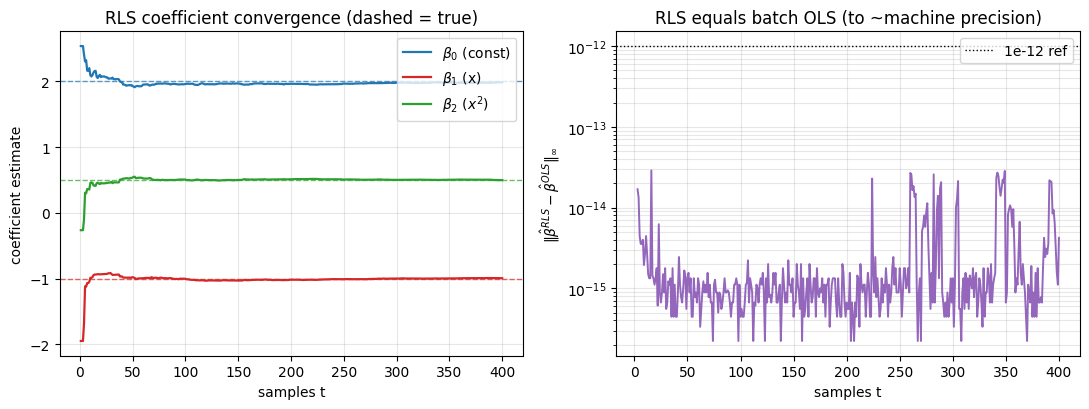

max RLS-OLS gap over t>=p : 2.89e-14


In [3]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))

ts = np.arange(1, T+1)
labels = [r"$\beta_0$ (const)", r"$\beta_1$ (x)", r"$\beta_2$ ($x^2$)"]
colors = ["#1f77b4", "#d62728", "#2ca02c"]
for j in range(p):
    ax[0].plot(ts, traj[:, j], color=colors[j], lw=1.6, label=labels[j])
    ax[0].axhline(beta_true[j], color=colors[j], ls="--", lw=1.0, alpha=0.7)
ax[0].set_xlabel("samples t"); ax[0].set_ylabel("coefficient estimate")
ax[0].set_title("RLS coefficient convergence (dashed = true)")
ax[0].legend(loc="best"); ax[0].grid(alpha=0.3)

# RLS vs batch OLS difference at every t (only for t >= p, where OLS is determined)
rls_ols = np.full(T, np.nan)
for t in range(p, T+1):
    bols, *_ = np.linalg.lstsq(Phi[:t], y[:t], rcond=None)
    rls_ols[t-1] = np.max(np.abs(traj[t-1] - bols)) + 1e-18
ax[1].semilogy(ts, rls_ols, color="#9467bd", lw=1.4)
ax[1].axhline(1e-12, color="k", ls=":", lw=1.0, label="1e-12 ref")
ax[1].set_xlabel("samples t"); ax[1].set_ylabel(r"$\|\hat\beta^{RLS}-\hat\beta^{OLS}\|_\infty$")
ax[1].set_title("RLS equals batch OLS (to ~machine precision)")
ax[1].legend(loc="best"); ax[1].grid(alpha=0.3, which="both")
plt.tight_layout(); plt.show()

print("max RLS-OLS gap over t>=p :", f"{rls_ols[p:].max():.2e}")

## 4. 결과 해석

1. **동치성**: 무릿지 초기화 덕분에 $t\ge p$ 인 모든 체크포인트에서 $\|\hat\beta^{RLS}_t-\hat\beta^{OLS}_t\|_\infty$ 가
   $10^{-12}$ 수준(반올림 오차)까지 내려간다. RLS 는 배치 OLS 를 근사하는 것이 아니라 **정확히 같은 해**를 재귀적으로 만든다.
   (릿지 초기화 $P_0=\delta^{-1}I$ 를 썼다면 이 격차는 $\mathcal O(\delta)$ 에서 멈춰 결코 사라지지 않는다.)
2. **수렴**: 좌측 궤적에서 세 계수 모두 참값 점선으로 빠르게 수렴한다. 잔여 요동은 관측잡음 $\sigma$ 에서 오는 것으로,
   $\hat\beta_t$ 의 분산은 대략 $\sigma^2\,\mathrm{tr}(P_t)\sim\mathcal O(1/t)$ 로 줄어든다.
3. **비용**: 매 스텝 갱신은 행렬-벡터 곱 몇 번, 즉 $\mathcal O(p^2)$ 이다. 배치를 매번 다시 푸는 $\mathcal O(tp^2)$ 와 달리
   스트림 길이 $t$ 에 무관하다 — **온라인 학습의 핵심 이점**.

> **결론**: RLS 는 정상 데이터에서 배치 OLS 와 기계정밀도로 동일하면서, 샘플당 $\mathcal O(p^2)$ 로 상수 시간 갱신을 준다.

**다음 문제로**: 여기서는 모든 과거를 **동일 가중**했다. Problem 2 에서는 **망각인자 $\lambda$** 로 과거를 지수감쇠시켜,
계수가 *시간에 따라 변하는* 비정상 환경을 추적하도록 확장한다.